
# Remaining Objectives — Validity, Interpretability, Supportive LLM 

This notebook completes the **remaining objective tasks** and produces evidence for the final report.


In [1]:

# === Config ===
DATA_DIR = "/kaggle/input/mentalhealthdata"  
PATTERN  = "*.csv"
OUTPUT_DIR = "/kaggle/working/figure_output"
SEED = 42
TFIDF_MAX_FEATURES = 200_000

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)


OUTPUT_DIR: /kaggle/working/figure_output


In [2]:

# === Imports ===
import os, glob, re, json, math, random, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.calibration import CalibrationDisplay

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

def ensure_outdir(p):
    if not os.path.exists(p):
        os.makedirs(p, exist_ok=True)

def plot_save(fig, path):
    ensure_outdir(os.path.dirname(path))
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved:", path)
    plt.close(fig)


In [3]:

# === Data loading & weak triage ===

def load_data(DATA_DIR: str, PATTERN: str) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(DATA_DIR, PATTERN)))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {DATA_DIR} with pattern {PATTERN}")
    dfs = []
    for p in files:
        df = pd.read_csv(p)
        if "category" not in df.columns:
            stem = os.path.splitext(os.path.basename(p))[0]
            token = stem.split("_", 1)[0] if "_" in stem else stem
            df.insert(0, "category", str(token).lower())
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)

    for c in ["Title", "Text", "Top_10_Comments", "category"]:
        if c in combined.columns:
            s = combined[c].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
            combined[c] = s.replace({"nan": ""})
        else:
            combined[c] = ""

    if "Created_At" in combined.columns:
        num = pd.to_numeric(combined["Created_At"], errors="coerce")
        dt_epoch = pd.to_datetime(num, unit="s", errors="coerce")
        dt_str = pd.to_datetime(combined["Created_At"], errors="coerce")
        combined["created_dt"] = dt_epoch.fillna(dt_str)

    combined["unified_text"] = (combined["Title"] + " " + combined["Text"] + " " + combined["Top_10_Comments"]).str.replace(r"\s+", " ", regex=True).str.strip()
    mask = (combined["unified_text"] != "") & (combined["unified_text"].str.split().str.len() > 3)
    combined = combined[mask].copy().reset_index(drop=True)
    return combined

def weak_triage_labels(df: pd.DataFrame) -> pd.DataFrame:
    text = (df["Title"].astype(str) + " " + df["Text"].astype(str) + " " + df["Top_10_Comments"].astype(str)).str.lower()
    kw_crisis = [
        "suicide","kill myself","end my life","want to die","self harm","self-harm",
        "overdose","can't go on","i'm done","ending it","hurt myself","hang myself"
    ]
    kw_red = [
        "hopeless","no way out","worthless","can't cope","severe","cutting","relapse",
        "panic attack","shaking","numb","empty all the time","voice telling me","visions"
    ]
    kw_amber = [
        "anxious","anxiety","depressed","depression","overwhelmed","crying",
        "can't sleep","insomnia","very stressed","please help","need help","advice please"
    ]
    pat_crisis = re.compile("|".join([re.escape(k) for k in kw_crisis]))
    pat_red    = re.compile("|".join([re.escape(k) for k in kw_red]))
    pat_amber  = re.compile("|".join([re.escape(k) for k in kw_amber]))

    has_crisis = text.str.contains(pat_crisis, na=False)
    has_red    = text.str.contains(pat_red,    na=False)
    has_amber  = text.str.contains(pat_amber,  na=False)

    triage = np.where(has_crisis, "crisis",
             np.where(has_red,    "red",
             np.where(has_amber,  "amber", "green")))
    df = df.copy()
    df["triage_weak"] = triage
    return df

df = load_data(DATA_DIR, PATTERN)
df = weak_triage_labels(df)
print("Rows:", len(df))
display(df.head(3)[["category","Title","triage_weak"]])


Rows: 10439


,category,Title,triage_weak
0,adhd,My son's ADHD saved his sister's life,green
1,adhd,Reminder: If you made it to adulthood with lat...,crisis
2,adhd,Children with higher IQ scores were diagnosed ...,amber


## A) Evaluation & Validity

In [4]:

def sample_gold_standard(df, n_per_label=80, seed=SEED):
    rs = np.random.RandomState(seed)
    out = []
    for lab in ["green","amber","red","crisis"]:
        dd = df[df["triage_weak"] == lab]
        k = min(n_per_label, len(dd))
        if k > 0:
            out.append(dd.sample(k, random_state=rs))
    if out:
        gold = pd.concat(out).sample(frac=1.0, random_state=rs).reset_index(drop=True)
    else:
        gold = df.sample(min(320, len(df)), random_state=rs).reset_index(drop=True)
    keep = ["category","Title","Text","Top_10_Comments","triage_weak"]
    for c in keep:
        if c not in gold.columns:
            gold[c] = ""
    gold = gold[keep]
    gold["annotator_A"] = ""
    gold["annotator_B"] = ""
    path = os.path.join(OUTPUT_DIR, "eval_gold_standard_template.csv")
    gold.to_csv(path, index=False)
    print("Saved:", path)

sample_gold_standard(df, n_per_label=80, seed=SEED)


Saved: /kaggle/working/figure_output/eval_gold_standard_template.csv


— Original features —
[original] macro-F1: 0.6891634804480616
Saved: /kaggle/working/figure_output/eval_pr_crisis_original.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_original.png
[original] ECE (crisis, 10-bin): 0.0661

— Masked diagnostic terms —
[masked] macro-F1: 0.663610375412456
Saved: /kaggle/working/figure_output/eval_pr_crisis_masked.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_masked.png
[masked] ECE (crisis, 10-bin): 0.0692


{'original': {'macro_f1': 0.6891634804480616,
  'crisis_recall': 0.7701612903225806},
 'masked': {'macro_f1': 0.663610375412456,
  'crisis_recall': 0.7600806451612904}}

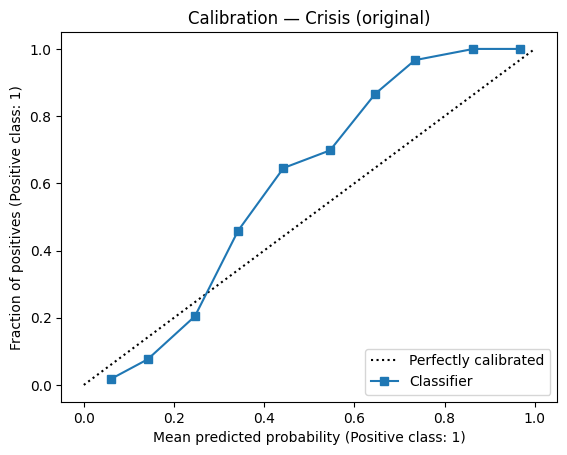

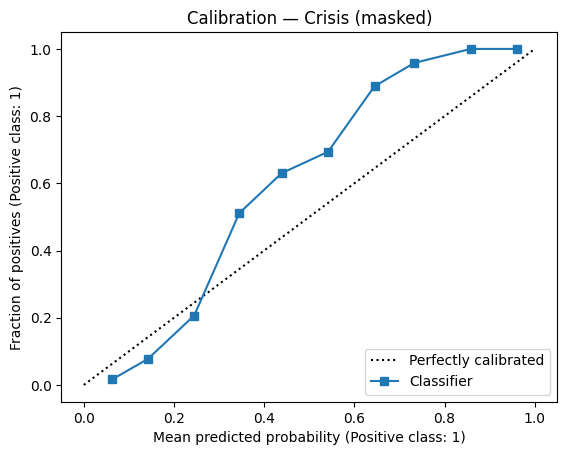

In [5]:

def mask_diagnostic_terms(texts, terms):
    pat = re.compile(r"\b(" + "|".join([re.escape(t.lower()) for t in terms]) + r")\b")
    def sub(s): return pat.sub("<<diag>>", str(s).lower())
    return np.array([sub(t) for t in texts])

def fit_eval(X, y, tag):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=TFIDF_MAX_FEATURES)
    XTR = vec.fit_transform(Xtr)
    XTE = vec.transform(Xte)
    clf = LogisticRegression(solver="saga", multi_class="multinomial", penalty="l2",
                             class_weight="balanced", max_iter=3000)
    clf.fit(XTR, ytr)
    ypred = clf.predict(XTE)
    ypro  = clf.predict_proba(XTE)
    rep = classification_report(yte, ypred, output_dict=True, digits=3)
    with open(os.path.join(OUTPUT_DIR, f"eval_leakage_{tag}.json"), "w") as f:
        json.dump(rep, f, indent=2)
    print(f"[{tag}] macro-F1:", rep["macro avg"]["f1-score"])
    # Crisis PR + calibration
    if "crisis" in clf.classes_:
        idx = list(clf.classes_).index("crisis")
        y_true = (yte == "crisis").astype(int)
        prec, rec, _ = precision_recall_curve(y_true, ypro[:, idx])
        ap = average_precision_score(y_true, ypro[:, idx])
        fig = plt.figure(figsize=(5.6,4.0))
        plt.plot(rec, prec, label=f"AP={ap:.3f}")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR — Crisis ({tag})"); plt.legend()
        plot_save(fig, os.path.join(OUTPUT_DIR, f"eval_pr_crisis_{tag}.png"))
        fig = plt.figure(figsize=(5.6,4.0))
        CalibrationDisplay.from_predictions(y_true, ypro[:, idx], n_bins=10)
        plt.title(f"Calibration — Crisis ({tag})")
        plot_save(fig, os.path.join(OUTPUT_DIR, f"eval_calibration_crisis_{tag}.png"))
        # ECE (10-bin)
        bins = np.linspace(0,1,11)
        ece = 0.0
        n = len(y_true)
        for i in range(10):
            lo, hi = bins[i], bins[i+1]
            m = (ypro[:, idx] >= lo) & (ypro[:, idx] < hi) if i < 9 else (ypro[:, idx] >= lo) & (ypro[:, idx] <= hi)
            if m.any():
                conf = ypro[m, idx].mean()
                acc  = y_true[m].mean()
                ece += (m.sum()/n) * abs(acc - conf)
        with open(os.path.join(OUTPUT_DIR, f"eval_ece_crisis_{tag}.json"), "w") as f:
            json.dump({"ece_10bin": float(ece)}, f, indent=2)
        print(f"[{tag}] ECE (crisis, 10-bin):", round(float(ece), 4))
    return rep

X_full = (df["Title"].astype(str) + " " + df["Text"].astype(str) + " " + df["Top_10_Comments"].astype(str)).values
y = df["triage_weak"].astype(str).values

print("— Original features —")
rep_orig = fit_eval(X_full, y, tag="original")

diag_terms = ["adhd","anxiety","ocd","bpd","ptsd","bipolar","panic","depression","depressed",
              "socialanxiety","mentalillness","mentalhealth","suicidewatch"]
print("\n— Masked diagnostic terms —")
rep_mask = fit_eval(mask_diagnostic_terms(X_full, diag_terms), y, tag="masked")

delta = {
    "original": {"macro_f1": rep_orig["macro avg"]["f1-score"], "crisis_recall": rep_orig.get("crisis",{}).get("recall", np.nan)},
    "masked":   {"macro_f1": rep_mask["macro avg"]["f1-score"], "crisis_recall": rep_mask.get("crisis",{}).get("recall", np.nan)}
}
with open(os.path.join(OUTPUT_DIR, "eval_leakage_delta.json"), "w") as f:
    json.dump(delta, f, indent=2)
delta


[sub_adhd] macro-F1: 0.019900497512437814
Saved: /kaggle/working/figure_output/eval_pr_crisis_sub_adhd.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_sub_adhd.png
[sub_adhd] ECE (crisis, 10-bin): 0.9176
[sub_anxiety] macro-F1: 0.24589371980676328
Saved: /kaggle/working/figure_output/eval_pr_crisis_sub_anxiety.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_sub_anxiety.png
[sub_anxiety] ECE (crisis, 10-bin): 0.0453
[sub_bipolar] macro-F1: 0.4876249045504627
Saved: /kaggle/working/figure_output/eval_pr_crisis_sub_bipolar.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_sub_bipolar.png
[sub_bipolar] ECE (crisis, 10-bin): 0.0878
[sub_bpd] macro-F1: 0.46233980211797954
Saved: /kaggle/working/figure_output/eval_pr_crisis_sub_bpd.png
Saved: /kaggle/working/figure_output/eval_calibration_crisis_sub_bpd.png
[sub_bpd] ECE (crisis, 10-bin): 0.0974
[sub_depression] macro-F1: 0.5202121864442901
Saved: /kaggle/working/figure_output/eval_pr_crisis_su

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

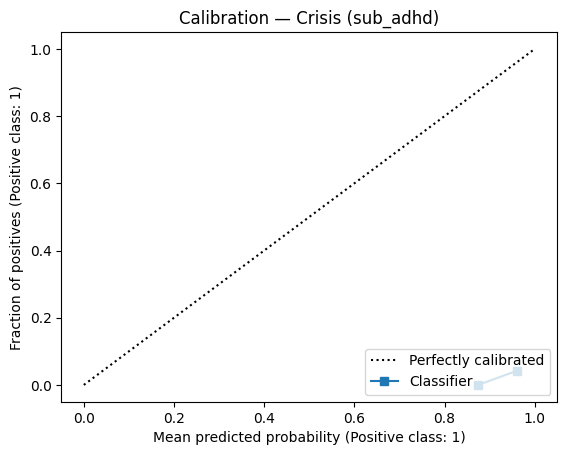

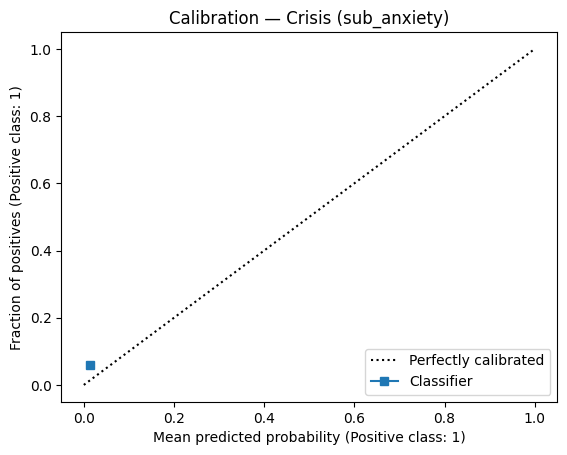

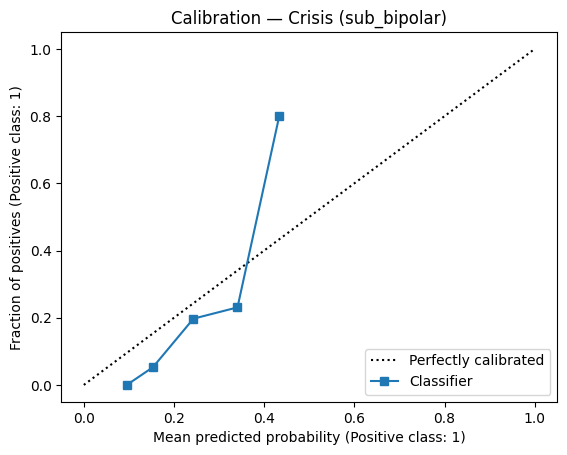

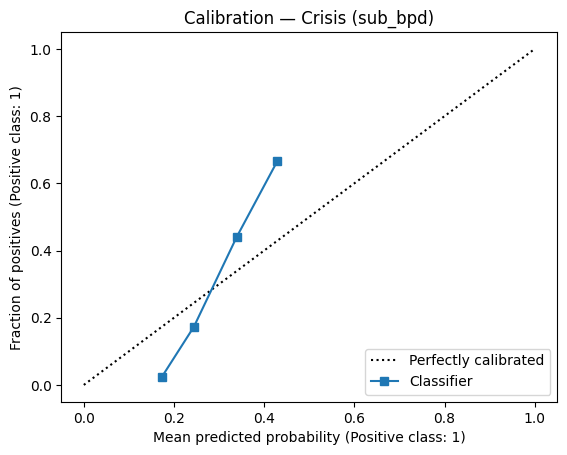

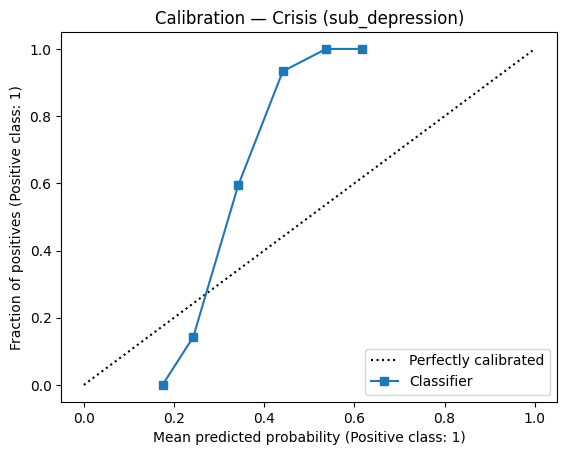

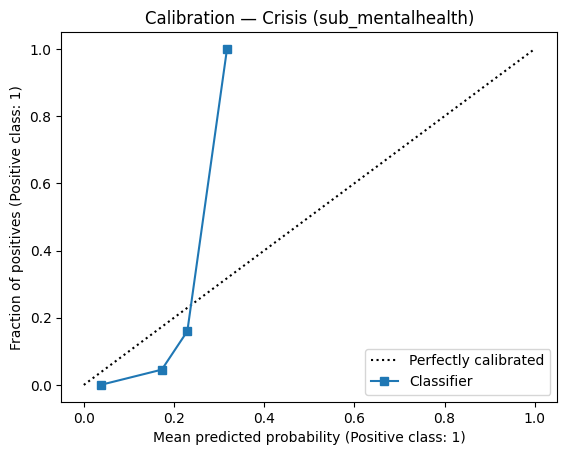

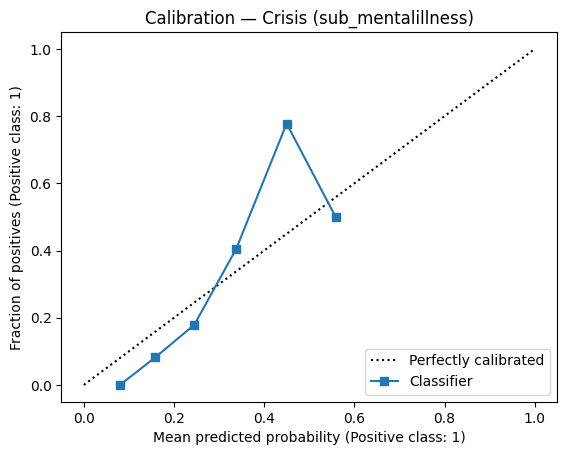

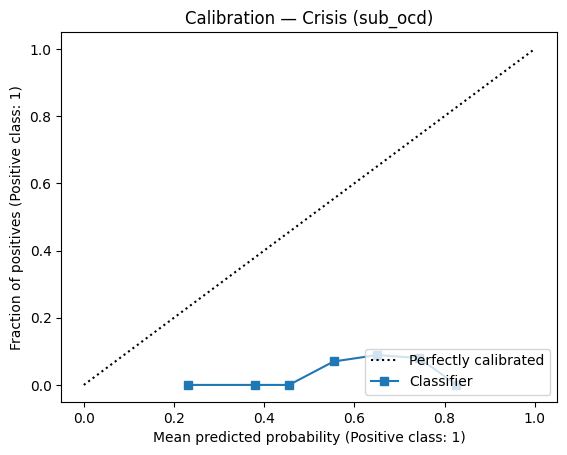

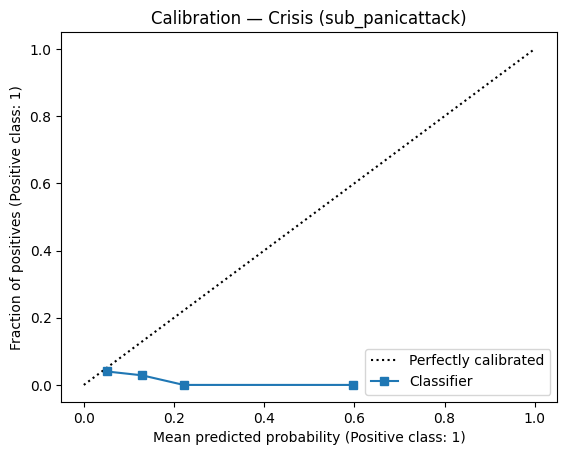

In [6]:

per_sub = []
subs = sorted(df["category"].astype(str).unique().tolist())
for sub in subs:
    mask = (df["category"].astype(str) == sub)
    Xs = X_full[mask]; ys = y[mask]
    if len(ys) < 100:
        continue
    rep = fit_eval(Xs, ys, tag=f"sub_{sub}")
    per_sub.append({"subreddit": sub, 
                    "macro_f1": rep["macro avg"]["f1-score"],
                    "crisis_recall": rep.get("crisis",{}).get("recall", np.nan)})
per_sub_df = pd.DataFrame(per_sub).sort_values("macro_f1", ascending=False)
display(per_sub_df.head(10))
per_sub_df.to_csv(os.path.join(OUTPUT_DIR, "eval_per_subreddit.csv"), index=False)
print("Saved:", os.path.join(OUTPUT_DIR, "eval_per_subreddit.csv"))


## B) Interpretability

In [7]:

X = X_full
y = df["triage_weak"].astype(str).values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=TFIDF_MAX_FEATURES)
XTR = vec.fit_transform(Xtr); XTE = vec.transform(Xte)

clf = LogisticRegression(solver="saga", multi_class="multinomial", penalty="l2", class_weight="balanced", max_iter=3000)
clf.fit(XTR, ytr)

feats = np.array(vec.get_feature_names_out())
tops = {}
for i, lab in enumerate(clf.classes_):
    coef = clf.coef_[i]
    idx = np.argsort(coef)[::-1][:25]
    tops[lab] = [(feats[j], float(coef[j])) for j in idx]

with open(os.path.join(OUTPUT_DIR, "intrp_top_ngrams_per_class.json"), "w") as f:
    json.dump(tops, f, indent=2)

print("Saved:", os.path.join(OUTPUT_DIR, "intrp_top_ngrams_per_class.json"))
tops


Saved: /kaggle/working/figure_output/intrp_top_ngrams_per_class.json


{'amber': [('anxiety', 4.657380288069333),
  ('anxious', 3.234085389485114),
  ('depression', 2.954890064746587),
  ('depressed', 2.081979543544919),
  ('social anxiety', 1.8246237912547332),
  ('social', 1.7407963131737838),
  ('crying', 1.480563181746915),
  ('my anxiety', 1.3510240069057087),
  ('overwhelmed', 1.232366911133253),
  ('people', 1.08565076645834),
  ('makes', 0.9537905976370175),
  ('adhd', 0.9416711288654682),
  ('rude', 0.8980316377809839),
  ('anxious and', 0.8252648615231486),
  ('bed', 0.8141851396225745),
  ('amazing', 0.8131855581526548),
  ('need help', 0.8115404733448403),
  ('awkward', 0.8105900484416425),
  ('anxiety and', 0.7994594165486134),
  ('like', 0.7369463184792616),
  ('used to', 0.7299028012292725),
  ('and anxiety', 0.7203232074355699),
  ('makes me', 0.7043652792855452),
  ('my social', 0.7007253204945602),
  ('enjoy', 0.7006073658865979)],
 'crisis': [('suicide', 8.412552223606784),
  ('kill myself', 4.256259159755621),
  ('die', 4.0455657594657

In [8]:

FPS = {"i","me","my","mine"}
SPS = {"we","us","our","ours"}
NEGS = {"no","not","never","nothing","nowhere","neither","n't"}

def liwc_proxies(text):
    toks = re.findall(r"[a-z']+", str(text).lower())
    n = len(toks) if len(toks)>0 else 1
    r1 = sum(w in FPS for w in toks)/n
    r2 = sum(w in SPS for w in toks)/n
    rn = sum(w in NEGS for w in toks)/n
    ttr = len(set(toks))/n
    return pd.Series([r1, r2, rn, ttr], index=["ratio_1p","ratio_we","ratio_neg","ttr"])

fx = pd.Series(X).apply(liwc_proxies)
dfp = pd.concat([df.reset_index(drop=True), fx.reset_index(drop=True)], axis=1)

order = ["green","amber","red","crisis"]
for col in ["ratio_1p","ratio_neg","ttr"]:
    fig = plt.figure(figsize=(6,4))
    means = [dfp.loc[dfp["triage_weak"]==lab, col].mean() for lab in order]
    plt.bar(order, means)
    plt.title(f"{col} by triage label")
    plot_save(fig, os.path.join(OUTPUT_DIR, f"intrp_{col}_by_label.png"))


Saved: /kaggle/working/figure_output/intrp_ratio_1p_by_label.png
Saved: /kaggle/working/figure_output/intrp_ratio_neg_by_label.png
Saved: /kaggle/working/figure_output/intrp_ttr_by_label.png


In [9]:

# Optional: SHAP explanations on a small subset (skip if SHAP not available)
try:
    import shap
    explainer = shap.LinearExplainer(clf, XTR, feature_perturbation="interventional")
    sample_idx = np.random.choice(XTE.shape[0], size=min(300, XTE.shape[0]), replace=False)
    shap_vals = explainer.shap_values(XTE[sample_idx])
    # Mean |SHAP| per feature for 'crisis' class if available
    if isinstance(shap_vals, list) and len(shap_vals) == len(clf.classes_):
        crisis_idx = list(clf.classes_).index("crisis") if "crisis" in clf.classes_ else 0
        mabs = np.abs(shap_vals[crisis_idx]).mean(axis=0)
        topk = np.argsort(mabs)[::-1][:25]
        top_table = pd.DataFrame({"feature": feats[topk], "mean_abs_shap": mabs[topk]})
        top_table.to_csv(os.path.join(OUTPUT_DIR, "intrp_shap_meanabs_crisis.csv"), index=False)
        print("Saved:", os.path.join(OUTPUT_DIR, "intrp_shap_meanabs_crisis.csv"))
    else:
        print("SHAP returned a single matrix; skipping class-specific export.")
except Exception as e:
    print("SHAP not available or failed gracefully:", e)


Saved: /kaggle/working/figure_output/intrp_shap_meanabs_crisis.csv


## C) Supportive LLM Demo

In [10]:

TEMPLATE = ("Thank you for sharing this. What you're feeling sounds hard. "
            "Here are a few gentle ideas: {tips} "
            "If anything feels overwhelming, shrink it to the smallest possible step. "
            "If you are in immediate danger or thinking about harming yourself, please contact your local emergency number.")

TIPS = {
    "anxiety": "slow breathing, limit caffeine, write one next step, and return attention to a present anchor.",
    "depression": "steady wake time, a two-minute movement, and finish one small task.",
    "default": "keep sleep regular, take a short walk, reduce late-night screens, reach out to someone you trust."
}

def safe_template(category: str):
    key = category.lower() if category and category.lower() in TIPS else "default"
    return TEMPLATE.format(tips=TIPS[key])

out = []
try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    tok = AutoTokenizer.from_pretrained("google/flan-t5-small")
    model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
    for _, row in df.sample(min(5, len(df)), random_state=SEED).iterrows():
        cat = str(row.get("category",""))
        prompt = (f"You are a supportive, non-clinical assistant. Category: {cat}\n"
                  f"Title: {row['Title']}\nPost: {row['Text']}\n"
                  "Write a short, compassionate response (120–180 words). Avoid medical advice.")
        inputs = tok([prompt], return_tensors="pt", truncation=True, max_length=512)
        out_ids = model.generate(**inputs, max_new_tokens=160, do_sample=True, top_p=0.9, temperature=0.7)
        draft = tok.decode(out_ids[0], skip_special_tokens=True)
        out.append({"category": cat, "title": row["Title"], "draft": draft})
    print("Transformers run succeeded; generated model-based drafts.")
except Exception as e:
    print("Transformers not available; using safe templates. Reason:", e)
    for _, row in df.sample(min(5, len(df)), random_state=SEED).iterrows():
        cat = str(row.get("category",""))
        out.append({"category": cat, "title": row["Title"], "draft": safe_template(cat)})

with open(os.path.join(OUTPUT_DIR, "llm_supportive_drafts.json"), "w") as f:
    json.dump(out, f, indent=2)
print("Saved:", os.path.join(OUTPUT_DIR, "llm_supportive_drafts.json"))
out[:2]


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Transformers run succeeded; generated model-based drafts.
Saved: /kaggle/working/figure_output/llm_supportive_drafts.json


[{'category': 'ptsd',
  'title': 'I’m supposed to be doing a project for school, but it’s nearly identical to my trauma',
  'draft': 'My Traumatic Stress Reduction'},
 {'category': 'mentalillness',
  'title': 'i have a good life, friends and everything but sometimes i still wish that i won’t wake up in the morning',
  'draft': 'I don’t want to be a therapist'}]

## Run Card & Environment

In [11]:
import datetime
import sys
import platform

run_card = {
    "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
    "python": sys.version,
    "platform": platform.platform(),
    "libs": {
        "numpy": np.__version__,
        "pandas": pd.__version__
    },
    "config": {
        "DATA_DIR": DATA_DIR,
        "PATTERN": PATTERN,
        "TFIDF_MAX_FEATURES": TFIDF_MAX_FEATURES,
        "SEED": SEED
    }
}
with open(os.path.join(OUTPUT_DIR, "run_card.json"), "w") as f:
    json.dump(run_card, f, indent=2)
print("Saved:", os.path.join(OUTPUT_DIR, "run_card.json"))

with open(os.path.join(OUTPUT_DIR, "DATASET_CARD.md"), "w") as f:
    f.write("# Dataset Card\n- Source: 12 mental-health subreddits (public posts)\n- Privacy: de-identified handles\n- Fields: title, body, time, upvotes, top comments\n- Bias: engagement bias, community norms\n- Use: research only\n")
with open(os.path.join(OUTPUT_DIR, "MODEL_CARD.md"), "w") as f:
    f.write("# Model Card\n- TF-IDF + Logistic Regression\n- Task: 4-way triage\n- Inputs: Post-only or Post+Comments\n- Safety: calibration & policy mapping\n- Limits: weak labels; domain shift\n")

print("Saved dataset and model cards to:", OUTPUT_DIR)


Saved: /kaggle/working/figure_output/run_card.json
Saved dataset and model cards to: /kaggle/working/figure_output


In [12]:
# --- Quiet down CUDA/protobuf noise & force CPU (optional but helpful on Kaggle) ---
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # use CPU for stability
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import json
import numpy as np
import pandas as pd
from IPython.display import display

# ---- Safety + templates ----
TEMPLATE = (
    "Thank you for sharing this. What you're feeling sounds hard. "
    "Here are a few gentle ideas: {tips} "
    "If anything feels overwhelming, shrink it to the smallest possible step. "
    "If you are in immediate danger or thinking about harming yourself, please contact your local emergency number."
)

TIPS = {
    "anxiety": "slow breathing, limit caffeine, write one next step, and return attention to a present anchor.",
    "depression": "steady wake time, a two-minute movement, and finish one small task.",
    "default": "keep sleep regular, take a short walk, reduce late-night screens, reach out to someone you trust."
}

CRISIS_TEMPLATE = (
    "I'm really sorry you're feeling this way. If you are in immediate danger or thinking about harming yourself, "
    "please contact your local emergency number right now. If you can, reach out to someone you trust. "
    "You deserve support and safety."
)

RISK_CUES = [
    "suicide","kill myself","end it","end my life","self harm","self-harm","cutting",
    "overdose","can't go on","want to die","hurt myself","hang myself","ending it"
]

def tip_for_category(cat: str) -> str:
    key = (cat or "").lower()
    return TIPS.get(key, TIPS["default"])

def with_tips(text: str, cat: str) -> str:
    return f"{text.rstrip()} " + TEMPLATE.format(tips=tip_for_category(cat))

def is_crisis_text(title: str, text: str, comments: str) -> bool:
    raw = f"{title} {text} {comments}".lower()
    return any(k in raw for k in RISK_CUES)

def adequate(draft: str, min_words: int = 40) -> bool:
    return len(draft.strip().split()) >= min_words

# ---- Try transformer; otherwise fallback to template-only ----
out = []
used_transformers = False
try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    tok = AutoTokenizer.from_pretrained("google/flan-t5-small")
    model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

    used_transformers = True
    rows = df.sample(min(5, len(df)), random_state=SEED)  # df + SEED assumed from previous cells

    for _, row in rows.iterrows():
        cat = str(row.get("category",""))
        title = str(row.get("Title",""))
        post  = str(row.get("Text",""))
        comm  = str(row.get("Top_10_Comments",""))

        # Hard safety gate
        if is_crisis_text(title, post, comm):
            model_draft = CRISIS_TEMPLATE
            final = with_tips(model_draft, cat)  # still append tips for consistency
        else:
            prompt = (
                "You are a supportive, non-clinical assistant. "
                "Read the user's post and write an empathetic, boundaried reply. "
                "Do not diagnose. Encourage professional help as appropriate.\n\n"
                f"Category: {cat}\n"
                f"Title: {title}\n"
                f"Post: {post}\n"
                f"Some comments: {comm}\n\n"
                "Write a short, compassionate response (120–180 words). "
                "Avoid medical advice. Offer gentle, practical next steps."
            )
            inputs = tok([prompt], return_tensors="pt", truncation=True, max_length=512)
            out_ids = model.generate(
                **inputs,
                max_new_tokens=180,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
            )
            model_draft = tok.decode(out_ids[0], skip_special_tokens=True)

            # If the model draft is too short/unhelpful, fall back to template
            if not adequate(model_draft):
                model_draft = TEMPLATE.format(tips=tip_for_category(cat))

            # Always append tips to make the reply concrete and consistent
            final = with_tips(model_draft, cat)

        out.append({
            "category": cat,
            "title": title[:140],
            "tips": tip_for_category(cat),
            "model_draft": model_draft,
            "final_reply": final
        })

    print("Transformers run succeeded; generated model-based drafts (tips appended).")

except Exception as e:
    print("Transformers not available or failed; using safe templates. Reason:", e)
    rows = df.sample(min(5, len(df)), random_state=SEED)
    for _, row in rows.iterrows():
        cat = str(row.get("category",""))
        title = str(row.get("Title",""))
        post  = str(row.get("Text",""))
        comm  = str(row.get("Top_10_Comments",""))

        if is_crisis_text(title, post, comm):
            base = CRISIS_TEMPLATE
        else:
            base = TEMPLATE.format(tips=tip_for_category(cat))

        final = with_tips(base, cat)
        out.append({
            "category": cat,
            "title": title[:140],
            "tips": tip_for_category(cat),
            "model_draft": base,
            "final_reply": final
        })

# ---- Show nicely in the notebook & save to disk ----
out_df = pd.DataFrame(out, columns=["category","title","tips","model_draft","final_reply"])
display(out_df)

json_path = os.path.join(OUTPUT_DIR, "llm_supportive_drafts_with_tips.json")
csv_path  = os.path.join(OUTPUT_DIR, "llm_supportive_drafts_with_tips.csv")
out_df.to_json(json_path, orient="records", indent=2, force_ascii=False)
out_df.to_csv(csv_path, index=False)
print("Saved:", json_path)
print("Saved:", csv_path)


Transformers run succeeded; generated model-based drafts (tips appended).


,category,title,tips,model_draft,final_reply
0,ptsd,"I’m supposed to be doing a project for school,...","keep sleep regular, take a short walk, reduce ...",I'm really sorry you're feeling this way. If y...,I'm really sorry you're feeling this way. If y...
1,mentalillness,"i have a good life, friends and everything but...","keep sleep regular, take a short walk, reduce ...",I'm really sorry you're feeling this way. If y...,I'm really sorry you're feeling this way. If y...
2,depression,Does anhedonia ever go away?,"steady wake time, a two-minute movement, and f...",– I've been meaning to get out of my depressio...,– I've been meaning to get out of my depressio...
3,depression,i will overcome this. i will.,"steady wake time, a two-minute movement, and f...","– Today is a chilly day, but you're getting ti...","– Today is a chilly day, but you're getting ti..."
4,mentalillness,I have this thing where loud noises make me fe...,"keep sleep regular, take a short walk, reduce ...",Thank you for sharing this. What you're feelin...,Thank you for sharing this. What you're feelin...


Saved: /kaggle/working/figure_output/llm_supportive_drafts_with_tips.json
Saved: /kaggle/working/figure_output/llm_supportive_drafts_with_tips.csv
